In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from GGDPC import DPC, GGDPC
from utils import plot_clusters

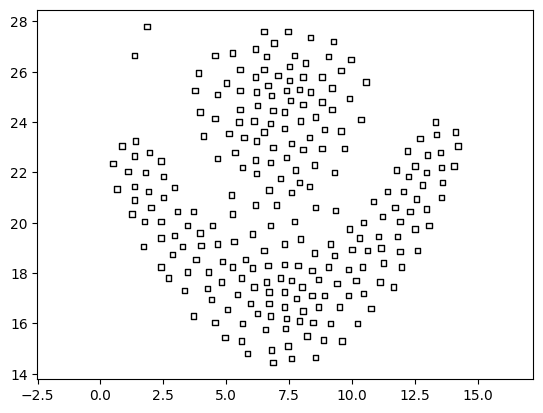

In [2]:
df = pd.read_csv("./Data/flame.txt", sep=r"\s+", header=None, names=["x", "y", "label"])
X_dat = df[["x", "y"]].values

plt.scatter(df["x"], df["y"], marker="s", facecolors="none", edgecolors="black", s=15)
plt.axis("equal")
plt.show()

In [9]:
df['label']

0      1
1      1
2      2
3      2
4      2
      ..
235    1
236    1
237    1
238    1
239    1
Name: label, Length: 240, dtype: int64

### Traditional DPC

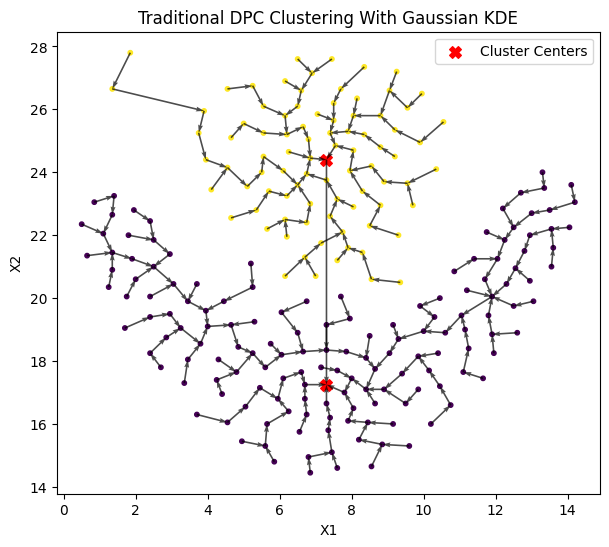

In [4]:
DPC_labels, DPC_det = DPC(X_dat, den_est=None, dist_mat=None, den_thres=0, center_quantile=None, 
                          return_details=True)

plt.figure(figsize=(7,6))
plot_clusters(X_dat, DPC_labels, np.arange(X_dat.shape[0])[DPC_det['1nn_higher'] != -1], 
              DPC_det['1nn_higher'][DPC_det['1nn_higher'] != -1], DPC_det['cluster_centers'], directed=True,
              title="Traditional DPC Clustering With Gaussian KDE")

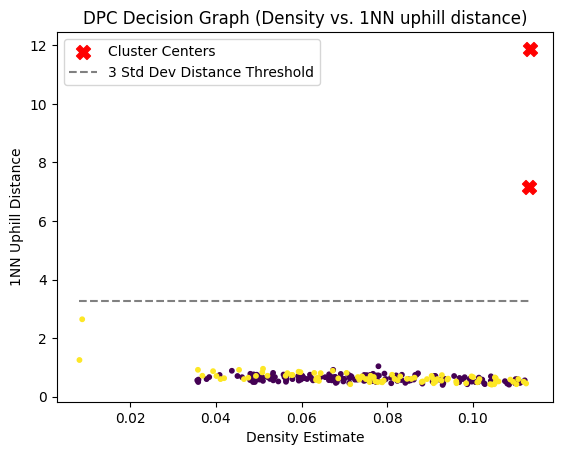

In [5]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression().fit(np.log(DPC_det['den_est']).reshape([-1,1]), np.log(DPC_det['delta']))

plt.scatter(DPC_det["den_est"], DPC_det["delta"], c=DPC_labels, cmap='viridis', s=10)
plt.scatter(DPC_det["den_est"][DPC_det["cluster_centers"]], DPC_det["delta"][DPC_det["cluster_centers"]], 
            c='red', marker='X', s=100, label='Cluster Centers')
# qry = np.linspace(min(DPC_det['den_est']), max(DPC_det['den_est']), 50)
# s_res = np.std(np.log(DPC_det['delta']) - lr.predict(np.log(DPC_det['den_est']).reshape([-1,1])), ddof=2)
# plt.plot(qry, np.exp(lr.intercept_ + lr.coef_ * np.log(qry) + 3*s_res), linewidth=3)
plt.hlines(y=3*np.std(DPC_det['delta']) + np.mean(DPC_det['delta']), xmin=min(DPC_det['den_est']), 
            xmax=max(DPC_det['den_est']), colors='grey', linestyles='dashed', label='3 Std Dev Distance Threshold')
plt.title("DPC Decision Graph (Density vs. 1NN uphill distance)")
plt.xlabel("Density Estimate")
plt.ylabel("1NN Uphill Distance")
plt.legend()
plt.show()

In [10]:
from sklearn.metrics import adjusted_rand_score

true_labels = df["label"].to_numpy()
pred_labels = np.asarray(DPC_labels)

ari = adjusted_rand_score(true_labels, pred_labels)
print(f"Adjusted Rand Index: {ari:.4f}")

Adjusted Rand Index: 1.0000


### GGDPC

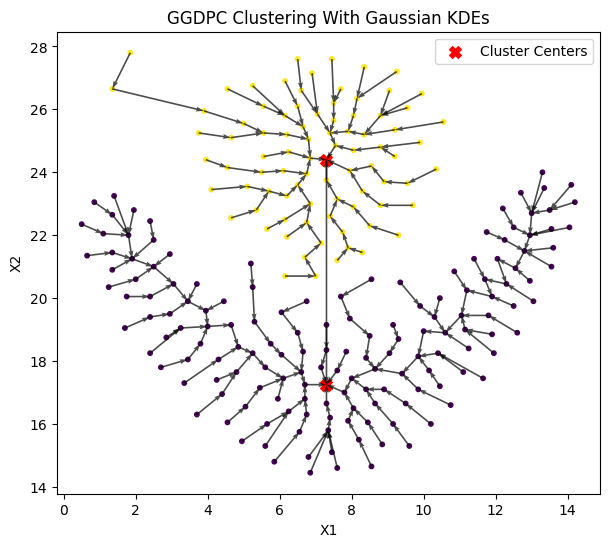

In [6]:
GGDPC_labels, GGDPC_det = GGDPC(X_dat, den_est=None, grad_new=None, den_thres=0, center_quantile=None, 
                                return_details=True)

plt.figure(figsize=(7,6))
plot_clusters(X_dat, GGDPC_labels, np.arange(X_dat.shape[0])[GGDPC_det['gg1nn_higher'] != -1], 
              GGDPC_det['gg1nn_higher'][GGDPC_det['gg1nn_higher'] != -1], GGDPC_det['cluster_centers'], 
              directed=True, title='GGDPC Clustering With Gaussian KDEs')

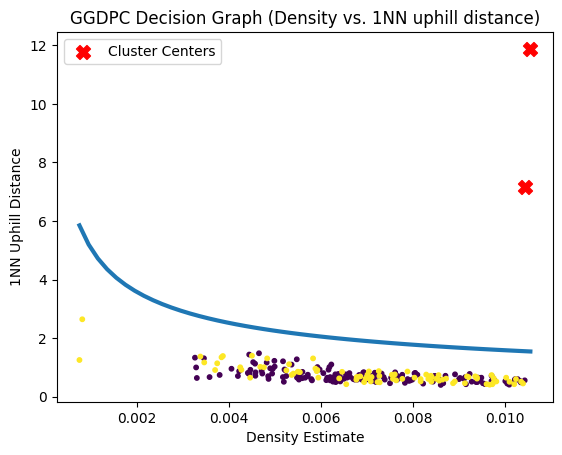

In [7]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression().fit(np.log(GGDPC_det['den_est']).reshape([-1,1]), np.log(GGDPC_det['delta']))

plt.scatter(GGDPC_det["den_est"], GGDPC_det["delta"], c=GGDPC_labels, cmap='viridis', s=10)
plt.scatter(GGDPC_det["den_est"][GGDPC_det["cluster_centers"]], GGDPC_det["delta"][GGDPC_det["cluster_centers"]], 
            c='red', marker='X', s=100, label='Cluster Centers')
qry = np.linspace(min(GGDPC_det['den_est']), max(GGDPC_det['den_est']), 50)
s_res = np.std(np.log(GGDPC_det['delta']) - lr.predict(np.log(GGDPC_det['den_est']).reshape([-1,1])), ddof=2)
plt.plot(qry, np.exp(lr.intercept_ + lr.coef_ * np.log(qry) + 3*s_res), linewidth=3)
plt.title("GGDPC Decision Graph (Density vs. 1NN uphill distance)")
plt.xlabel("Density Estimate")
plt.ylabel("1NN Uphill Distance")
plt.legend()
plt.show()

In [11]:
from sklearn.metrics import adjusted_rand_score

true_labels = df["label"].to_numpy()
pred_labels = np.asarray(GGDPC_labels)

ari = adjusted_rand_score(true_labels, pred_labels)
print(f"Adjusted Rand Index: {ari:.4f}")

Adjusted Rand Index: 0.9666
